## Intercomparison of inverse modelling results

This notebook contains options to plot and compare results from different inverse models. The following variables can be investigated:

- Posterior and prior country fluxes, total from all sectors, and respective uncertainties
- Observed and posterior/prior modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior bias mole fractions
- Posterior and prior mole fractions from the outer regions
- Observed repeatability/variability, model and total uncertainties
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Input data:

- Flux and concentration netCDF files with model outputs
- json files with models, sites and species information
- (optional) netCDF file with country fluxes from bottom-up inventory
- (optional) netCDF file with baseline timestamps

Please refer to the User Guide for information on files format, filename convention and folder structure.

### Notebook setup:

1. Decide the verbosity level by assigning the logging level to `logging.INFO` or `logging.WARNING`.

2. Edit the `data_dir` to point towards where the model output is.

3. Set `presentation_mode` to `True`/`False` to use big font sizes (recommended for slides) or small font sizes (recommended for text documents). 

4. Update the `experiments` dictionary so that each key points towards the models you want to plot.

5. Run the cell below, before running any of the plotting code.

THIS NOTEBOOK HAS BEEN USED TO PRODUCE HFC PAPER'S FIGURES

In [1]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxy.config import set_print_settings
from fluxy.io import read_config_files

### Path to results directory 
data_dir = '/user/home/qq24644/work/my_paris/NID2026'

### Set presentation_mode to True for bigger fonts
presentation_mode = True

### Group the models of interest in meaningful experiment names 
experiments = {'nid2026'                :['InTEM_NAME', 'InTEM_FLEXPART', 'ELRIS_NAME', 'ELRIS_FLEXPART', 'RHIME_NAME', 'RHIME_FLEXPART'],
               'nid2026_name'           :['InTEM_NAME', 'ELRIS_NAME', 'RHIME_NAME'],
               'nid2026_flexpart'       :['InTEM_FLEXPART', 'ELRIS_FLEXPART', 'RHIME_FLEXPART'],
               'network_effect_name'    :['InTEM_NAME', 'ELRIS_NAME', 'RHIME_NAME', 'InTEM_NAME_7sites', 'ELRIS_NAME_7sites', 'RHIME_NAME_7sites'],
               'network_effect_flexpart':['InTEM_FLEXPART', 'ELRIS_FLEXPART', 'RHIME_FLEXPART', 'InTEM_FLEXPART_7sites', 'ELRIS_FLEXPART_7sites', 'RHIME_FLEXPART_7sites'],
              }

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

### 1. Timeseries of country/region fluxes

Instructions to reproduce figures from the paper
- set `presentation_mode = True` for Flux Figures
- set `presentation_mode = False` for MF Figures

##### Edit and run this cell to read and pre-process the data:

In [30]:
from fluxy.io import read_model_output, read_flux_total_fgases
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'hfc32' #options for individual species, or 'all_hfc' or 'all_pfc'
models = experiments['nid2026'] #if using 'all_hfc' or 'all_pfc' use basic model names  (e.g. ['InTEM','ELRIS','RHIME']) and standard filenames (listed in config_data["models_info"]["standard_run"]["default"]) will be used for each species. 
                                #To use non standard filenames, do <model>_<config_key> : e.g. with ['ELRIS_elris-n2o'], the filenames will be looked in config_data["models_info"]["standard_run"]["elris-n2o"].
regions = ['NW_EU2', 'FRANCE', 'BENELUX', 'UK', 'GERMANY', 'IRELAND'] #regions to plot fluxes for. Must be in config_data["regions"]
period = 'yearly' #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
country_flux_units_print = 'Tg CO2-eq yr-1' #desired units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
start_date = '2013-01-01' #inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
end_date = '2025-01-01' #not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
get_labels_from_file = False # If False, uses default labels. If True, uses labels in models_info.json.
read_standard_run = True
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename 

#### Timeseries of country fluxes:

Instructions to reproduce figures from the paper
- Fig. 1--4, 6 ==> run with # Main Figure uncommented (and comment # Appendix Figure)
- Fig. A1 ==> set rolling_mean to False (and comment # Appendix Figure) DON'T FORGET TO PUT IT BACK TO TRUE AFTER
- Fig. A2--A5, A7 ==> comment # Main Figure and uncomment # Appendix Figure

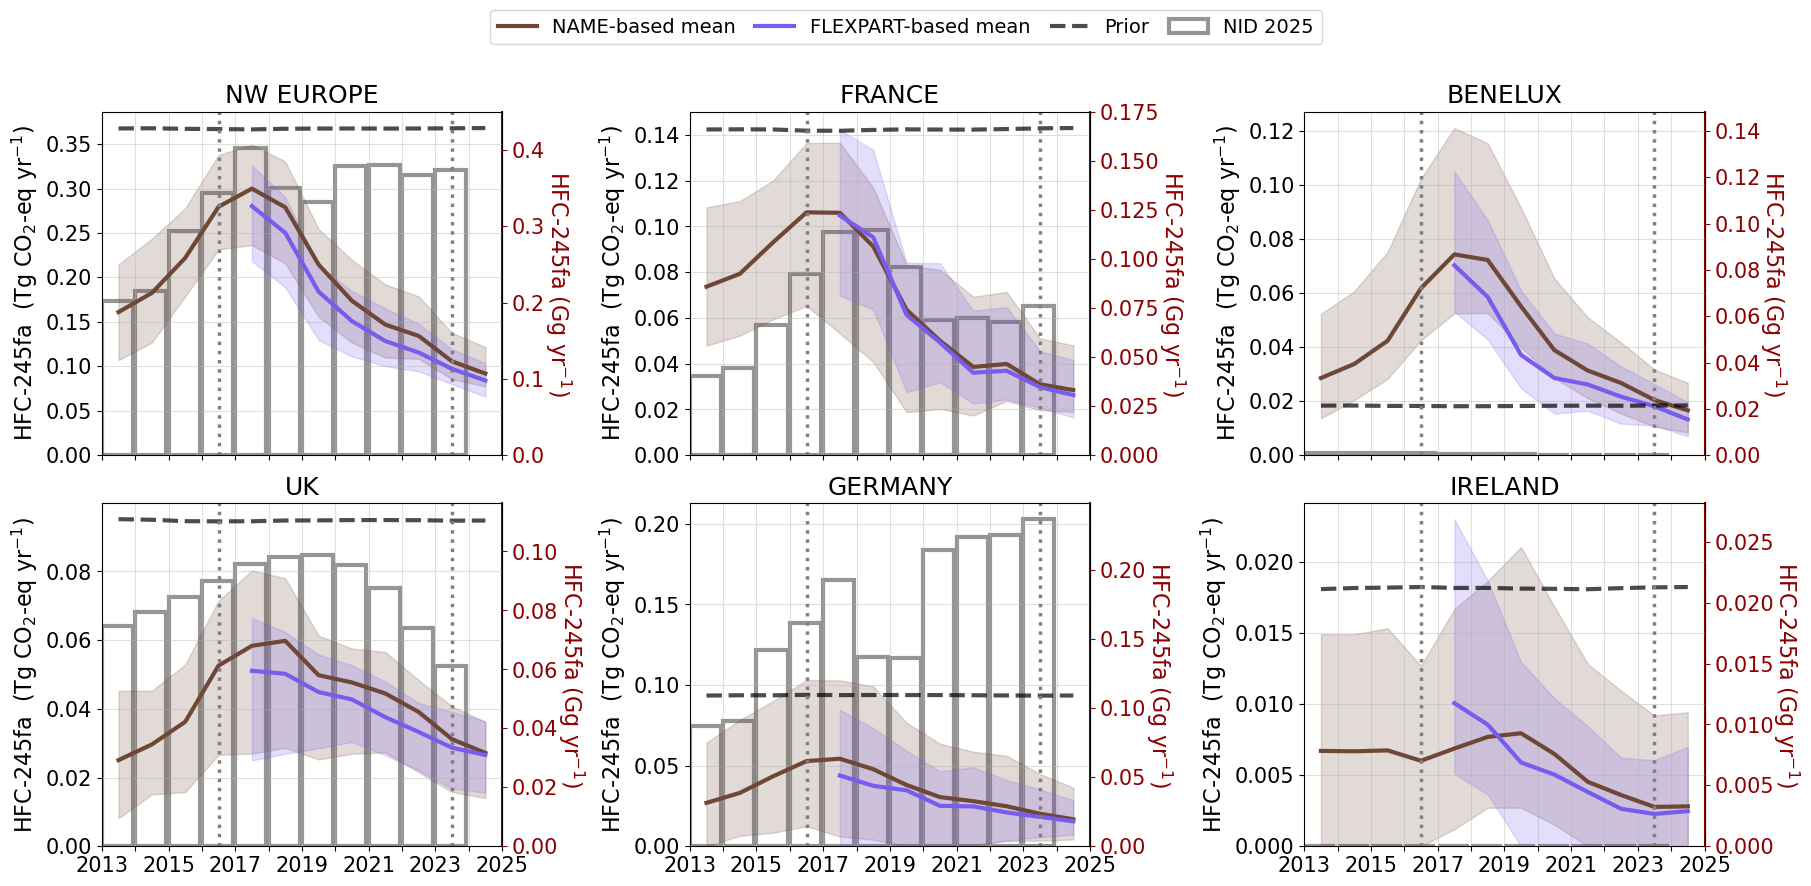

In [6]:
from fluxy.plots.flux_timeseries import plot_country_flux

###################################
### edit variables in this block
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
# add_prior = True #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
# plot_separate = False #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_separate_unc = True #If True, includes all model uncertainty as shaded areas
# plot_combined = True #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
plot_combined_unc = True #If True, includes combined uncertainty as shaded area
combined_models_dict = {
    'NAME-based mean': ['InTEM_NAME', 'ELRIS_NAME', 'RHIME_NAME'],
    'FLEXPART-based mean': ['InTEM_FLEXPART', 'ELRIS_FLEXPART','RHIME_FLEXPART'],
}
annex_mode = True #If True, replace the labels with more concise versions for NID Annexes.
# rolling_mean = False  # If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
###################################
# Main figure
add_prior = True
plot_separate = False
plot_combined = True
rolling_mean = True
add_vline = ['2016-07-02', '2023-07-02']
add_secondary_units = 'Gg yr-1'
add_Gg_per_year_axis = True
figname = f'{species}_flux_timeseries'

# Appendix figure
# add_prior = False
# plot_separate = True
# plot_combined = False
# rolling_mean = False
# add_vline = ['2016-07-02', '2023-07-02']
# add_Gg_per_year_axis = True
# figname = f'{species}_flux_timeseries_appendix'
###################################

fig, res = plot_country_flux(ds_all_flux_scaled,
                        species,
                        regions,
                        config_data,
                        model_colors,
                        model_labels,
                        start_date,
                        end_date,
                        annex_mode,
                        plot_inventory,
                        inventory_years,
                        inventory_filename,
                        data_dir,
                        fix_y_axes,
                        add_prior,
                        add_prior_unc,
                        set_global_leg,
                        plot_separate=plot_separate,
                        plot_separate_unc=plot_separate_unc,
                        plot_combined=plot_combined,
                        plot_combined_unc=plot_combined_unc,
                        combined_models_dict=combined_models_dict,
                        rolling_mean=rolling_mean,
                        add_vline=add_vline,
                        add_Gg_per_year_axis = add_Gg_per_year_axis,
                        return_res=True)

Save plot here:

In [8]:
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

Table of country flux trends:
--> used for Table 2

In [ ]:
import my_fluxy_paper_functions as func

emissions_df = func.reshape_emissions(res)
func.summarize_emissions(emissions_df, ["NW_EU2", "UK"], 2016, 2023)


In [ ]:
emissions_df[emissions_df["source"] == "NAME-based mean"]

##### Global emissions from AGAGE-12 box model (2022 Ozone Assement)

In [ ]:
gwp = config_data['species_info']

# 2020 Global emission values for each species (emission, uncertainty)
emission_Gg = {
    "hfc134a":  (247, 28),
    "hfc23":    (17, 0.8),
    "hfc125":   (92, 6),
    "hfc143a":  (31, 2),
    "hfc32":    (70, 7),
    "hfc152a":  (54, 8),
    "hfc245fa": (14, 2),
    "hfc227ea": (6.3, 0.7),
    "hfc365mfc": (4.3, 1),
    "hfc236fa": (0.39, 0.09),
    "hfc4310mee": (1.2, 0.3),
}

# Conversion Gg/yr to Tg CO2-eq/yr
emission_Tg_CO2eq = {
    sp: {
        "value": val * gwp[sp]["gwp"] / 1000,
        "unc":   unc * gwp[sp]["gwp"] / 1000
    }
    for sp, (val, unc) in emission_Gg.items()
}

# Total emissions
total = sum(v["value"] for v in emission_Tg_CO2eq.values())

In [ ]:
# Choose target species
target_sp = "hfc32"

target = emission_Tg_CO2eq[target_sp]["value"]
target_unc = emission_Tg_CO2eq[target_sp]["unc"]

print(f"Global emission in 2020: {target:.0f} ± {target_unc:.0f}, "
      f"{100 * target / total:.0f}% of total HFCs")

##### 2023 Global emissions from AGAGE-12 box model (Western et al. 2025)

In [ ]:
gwp = config_data['species_info']

# 2020 Global emission values for each species (emission, uncertainty)
emission_Gg = {
    "hfc134a":  (265, 31),
    "hfc23":    (14, 0.8),
    "hfc125":   (111, 8),
    "hfc143a":  (34, 3),
    "hfc32":    (100, 13),
    "hfc152a":  (57, 8.6), 
    "hfc245fa": (14, 2.8),
    "hfc227ea": (7.4, 0.8),
    "hfc365mfc": (3.4, 1.5),
    "hfc236fa": (0.43, 0.12),
    "hfc4310mee": (1.1, 0.46),
}

# Conversion Gg/yr to Tg CO2-eq/yr
emission_Tg_CO2eq = {
    sp: {
        "value": val * gwp[sp]["gwp"] / 1000,
        "unc":   unc * gwp[sp]["gwp"] / 1000
    }
    for sp, (val, unc) in emission_Gg.items()
}

# Total emissions
total = sum(v["value"] for v in emission_Tg_CO2eq.values())

In [ ]:
# Choose target species
target_sp = "hfc32"

target = emission_Tg_CO2eq[target_sp]["value"]
target_unc = emission_Tg_CO2eq[target_sp]["unc"]

print(f"Global emission in 2023: {target:.0f} ± {target_unc:.0f}, "
      f"{100 * target / total:.0f}% of total HFCs")

In [ ]:
for target_sp in list(emission_Tg_CO2eq.keys()):
      target = emission_Tg_CO2eq[target_sp]["value"]
      target_unc = emission_Tg_CO2eq[target_sp]["unc"]

      print(f"{target_sp}: Global emission in 2023: {target:.0f} ± {target_unc:.0f}, "
            f"{100 * target / total:.0f}% of total HFCs")

#### 2023 NWEU Contributions from the NAME-based and the FLEXPART-based means

In [ ]:
name = 28.8 
flexpart = 25.4
box = 1154

mean = (name + flexpart)/2
contribution = mean / box * 100
contribution

In [ ]:
emission_NAME_mean = {
    "hfc134a":  11,
    "hfc23":    1.3,
    "hfc125":   8.9,
    "hfc143a":  5.1,
    "hfc32":    0.8,
    "hfc152a":  0.09,
    "hfc245fa": 0.1,
    "hfc227ea": 0.6,
    "hfc365mfc":0.2,
    "hfc236fa": 0.07,
    "hfc4310mee":0.04,
    "total":    28.8
}

emission_FLEXPART_mean = {
    "hfc134a":  9.6,
    "hfc23":    1.1,
    "hfc125":   8.0,
    "hfc143a":  4.5,
    "hfc32":    1.3,
    "hfc152a":  0.04,
    "hfc245fa": 0.1,
    "hfc227ea": 0.5,
    "hfc365mfc":0.2,
    "hfc236fa": 0.06,
    "hfc4310mee":0.04,
    "total":    25.4
}

In [ ]:
name_tot = emission_NAME_mean["total"]
flexpart_tot = emission_FLEXPART_mean["total"]
for target_sp in list(emission_NAME_mean.keys()):
      name = emission_NAME_mean[target_sp]
      flexpart = emission_FLEXPART_mean[target_sp]
      print(target_sp)
      print(f"NAME {100 * name / name_tot:.0f}% and FLEXPART {100 * flexpart / flexpart_tot:.0f}% of total HFCs")

##### NWEU Contributions of each HFC to the Total over 2013-2024

In [ ]:
emission_NAME_mean = {
    "hfc134a":  (12.63, 1.00),
    "hfc23":    (1.38, 0.69),
    "hfc125":   (10.03, 0.81),
    "hfc143a":  (8.24, 0.71),
    "hfc32":    (1.04, 0.11),
    "hfc152a":  (0.07, 0.02),
    "hfc245fa": (0.19, 0.05),
    "hfc227ea": (0.59, 0.14),
    "hfc365mfc":(0.35, 0.06),
    "hfc236fa": (0.07, 0.04),
    "hfc4310mee":(0.05, 0.02),
    "total":    (34.65, 2.13)
}

emission_NAME_mean = {
    sp: {
        "value": val,
        "unc":   unc
    }
    for sp, (val, unc) in emission_NAME_mean.items()
}

In [ ]:
# Choose target species
target_sp = "hfc23"

target = emission_NAME_mean[target_sp]["value"]
target_unc = emission_NAME_mean[target_sp]["unc"]
total = emission_NAME_mean["total"]["value"]

print(f"NWEU emission in 2013-2024: {target:.0f} ± {target_unc:.0f}, "
      f"{100 * target / total:.0f}% of total HFCs")

#### Regional timeseries of multiple species:

Instructions to reproduce figures from the paper
- Fig. 5 ==> run with # Main Figure uncommented (and comment # Appendix Figure)
- Fig. A6 ==> comment # Main Figure and uncomment # Appendix Figure

/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename 

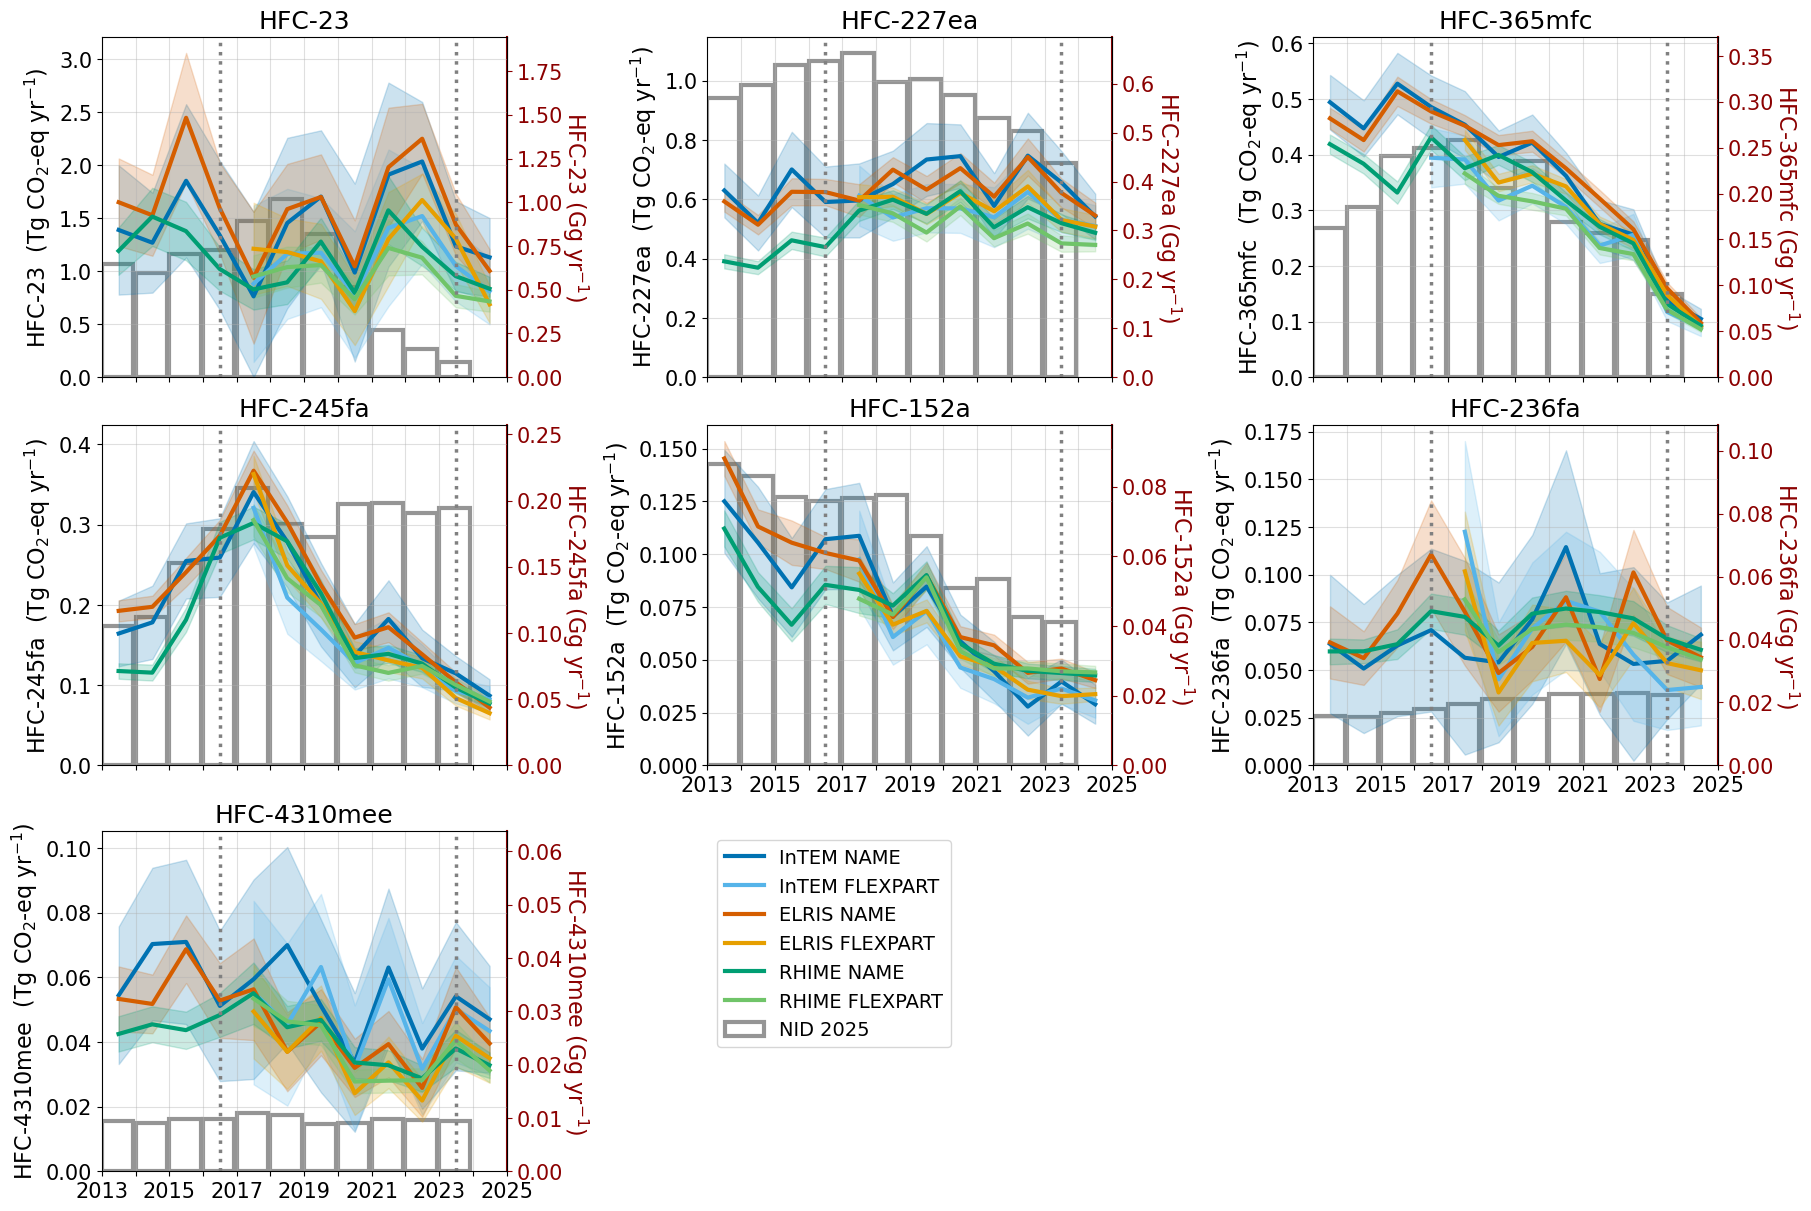

In [5]:
import hfc_paper_functions as func

# Main figure
# add_prior = False
# plot_separate = False
# plot_combined = True
# rolling_mean = True
# add_vline = ['2016-07-02', '2023-07-02']
# add_Gg_per_year_axis = True
# figname = 'minor_hfcs_flux_timeseries'

# Appendix figure
add_prior = False
plot_separate = True
plot_combined = False
rolling_mean = False
add_vline = ['2016-07-02', '2023-07-02']
add_Gg_per_year_axis = True
figname = 'minor_hfcs_flux_timeseries_appendix'
###################################

gases = ['hfc23','hfc227ea','hfc365mfc','hfc245fa','hfc152a','hfc236fa','hfc4310mee']
region = 'NW_EU2'

kwargs_read_model_output = {
    'models': models,
    'read_standard_run': read_standard_run,
    'data_dir': data_dir,
    'config_data': config_data,
}

kwargs_slice_flux = {
    'start_date': start_date,
    'end_date': end_date,
    'country_flux_units_print': country_flux_units_print,
}

kwargs_plot_country_flux = {
    'annex_mode': annex_mode,
    'plot_inventory': plot_inventory,
    'add_prior': add_prior,
    'add_prior_unc': add_prior_unc,
    'set_global_leg': set_global_leg,
    'plot_separate': plot_separate,
    'plot_separate_unc': plot_separate_unc,
    'plot_combined': plot_combined,
    'plot_combined_unc': plot_combined_unc,
    'rolling_mean': rolling_mean,
    'add_vline': add_vline,
    'add_Gg_per_year_axis': add_Gg_per_year_axis,
    'combined_models_dict': combined_models_dict,
}

fig = func.plot_multi_species_flux(
    gases = gases,
    region = region, 
    **kwargs_read_model_output, 
    **kwargs_slice_flux, 
    **kwargs_plot_country_flux)

In [11]:
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Population correlation with emissions trends

In [11]:
import pandas as pd
import xarray as xr

# Read emission results

ds = (
    res[res['model'] == "NAME-based mean"]
    .set_index(["time", "country"])
    .to_xarray()
)[["mean_val", "min_unc", "max_unc"]]

ds['time'] = pd.to_datetime(ds['time'].dt.year, format="%Y") + pd.DateOffset(months=6)

inventory = (
    res[res['model'] == "inventory_2025"]
    .set_index(["time", "country"])
    .to_xarray()
)[["mean_val"]]
inventory['time'] = pd.to_datetime(inventory['time'].dt.year, format="%Y") + pd.DateOffset(months=6)
inventory = inventory.reindex_like(ds)

ds = ds.assign(inventory=inventory['mean_val'])

# Read population data

df_pop = pd.read_csv("/user/home/qq24644/work/my_paris/estat_tps00001.tsv", sep="\t")
df_pop["country"] = df_pop.iloc[:, 0].str.split(",").str[-1]
df_pop = df_pop.drop(columns=df_pop.columns[0])

country_map = {
    "UK": "UK", 
    "FR": "FRANCE",
    "DE": "GERMANY",
    "IE": "IRELAND",
    "NL": "NETHERLANDS",
    "BE": "BELGIUM",
    "LU": "LUXEMBOURG",
}

df_pop = (
    df_pop[df_pop["country"].isin(country_map)]
    .assign(country=lambda d: d["country"].map(country_map))
)
df_pop = df_pop.replace(': ', pd.NA)
cols = df_pop.columns.difference(["country"])
df_pop[cols] = (
    df_pop[cols]
    .replace(': ', pd.NA)
    .replace(r"[^\d.]", "", regex=True)
    .apply(pd.to_numeric, errors="coerce")
    )

df_pop.loc[df_pop["country"] == "UK", ["2021 ", "2022 ", "2023 ", "2024 "]] = [66977988, 67636134, 68526183, 69281437]

df_pop = df_pop.melt(
    id_vars="country",
    var_name="year",
    value_name="pop"
)

df_pop["time"] = pd.to_datetime(df_pop["year"].astype(str).str.strip(), format="%Y") + pd.DateOffset(months=6)

pop_da = (
    df_pop
    .set_index(["time", "country"])
    .to_xarray()["pop"]
)

benelux = pop_da.sel(country=["BELGIUM", "NETHERLANDS", "LUXEMBOURG"]).sum(dim="country")
benelux = benelux.expand_dims("country").assign_coords(country=["BENELUX"])

nweu = pop_da.sel(country=["BELGIUM", "NETHERLANDS", "LUXEMBOURG", "IRELAND", "UK", "FRANCE", "GERMANY"]).sum(dim="country")
nweu = nweu.expand_dims("country").assign_coords(country=["NW_EU2"])

pop_da = xr.concat([pop_da, benelux, nweu], dim="country")
pop_da = pop_da.drop_sel(country=["BELGIUM", "NETHERLANDS", "LUXEMBOURG"])

pop_da = pop_da.reindex(
    time=ds.time,  # target times from ds
    method=None    # no interpolation, missing → NaN
)

# Add population data to ds
ds = ds.assign(population=pop_da)

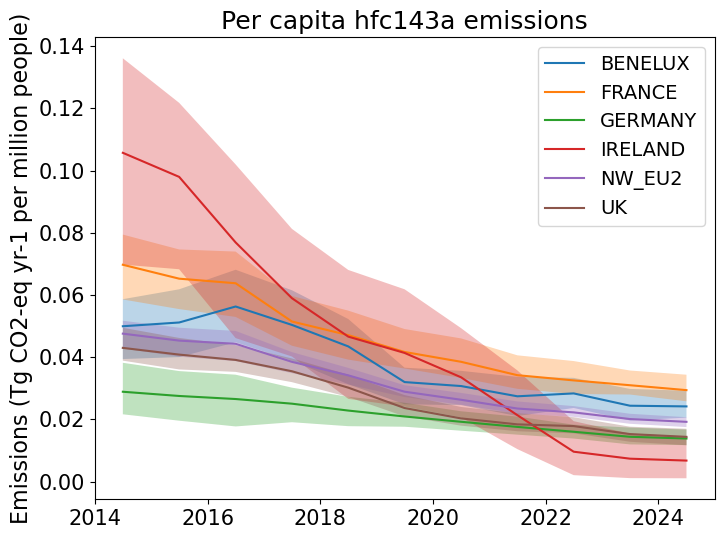

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,6))
for country in ds.country.values:
    pop = ds['population'].sel(country=country)
    per_capita_mean_val = ds['mean_val'].sel(country=country) / pop * 1e6  # per million people
    per_capita_min_unc = ds['min_unc'].sel(country=country) / pop * 1e6
    per_capita_max_unc = ds['max_unc'].sel(country=country) / pop * 1e6
    per_capita_mean_val.plot(ax=ax, label=country)
    ax.fill_between(
        per_capita_mean_val.time,
        per_capita_min_unc,
        per_capita_max_unc,
        alpha=0.3
    )
ax.set_ylabel('Emissions (Tg CO2-eq yr-1 per million people)')
ax.set_xlabel('')
ax.set_title(f'Per capita {species} emissions')
ax.legend()

In [ ]:
figname = f'{species}_em_per_capita'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

Text(0.5, 1.0, 'hfc143a: Population-based vs Inversion emissions on 2023-07-01')

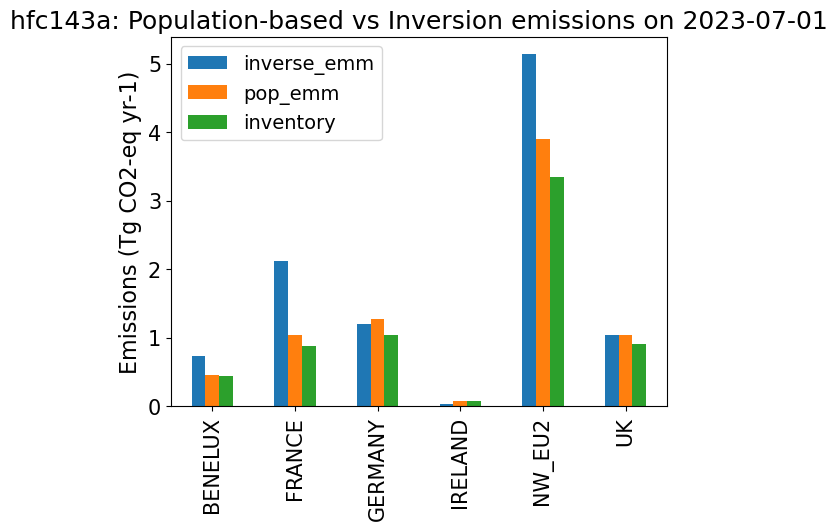

In [13]:
date = "2023-07-01"

ds_a = ds.sel(time=pd.to_datetime(date))

# ref_em_pop = float(ds_a.sel(country="NW_EU2").mean_val.values) / float(ds_a.sel(country="NW_EU2").population.values)
ref_em_pop = float(ds_a.sel(country="UK").mean_val.values) / float(ds_a.sel(country="UK").population.values)

df = pd.DataFrame({
    "country": ds_a.country.values,
    "inverse_emm": ds_a.mean_val.values,
    "pop_emm": ds_a.population.values*ref_em_pop,
    "inventory": ds_a.inventory.values
})
df.set_index("country").plot(kind="bar")
plt.ylabel("Emissions (Tg CO2-eq yr-1)")
plt.xlabel("")
plt.title(f"{species}: Population-based vs Inversion emissions on {date}")


In [ ]:
figname = f'{species}_pop_vs_inv_emissions'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Merging two png files into one figure

In [10]:
from PIL import Image

# Load the images
# fn1 = '/user/home/qq24644/my_paris/HFC_paper/figures/hfc134a_flux_map_flexpartVSname.png'
# fn2 = '/user/home/qq24644/my_paris/HFC_paper/figures/hfc143a_flux_map_flexpartVSname.png'
fn1 = '/user/home/qq24644/my_paris/HFC_paper/figures/hfc134a_network_effect_flexpart.png'
fn2 = '/user/home/qq24644/my_paris/HFC_paper/figures/hfc143a_network_effect_flexpart.png'
img1 = Image.open(fn1)
img2 = Image.open(fn2)

# Option 1: Merge horizontally
# total_width = img1.width + img2.width
# max_height = max(img1.height, img2.height)

# merged = Image.new("RGBA", (total_width, max_height), (255, 255, 255, 0))  # transparent background
# merged.paste(img1, (0, 0))
# merged.paste(img2, (img1.width, 0))

# Option 2: Merge vertically
total_height = img1.height + img2.height
max_width = max(img1.width, img2.width)
merged = Image.new("RGBA", (max_width, total_height), (255, 255, 255, 0))
merged.paste(img1, (0, 0))
merged.paste(img2, (0, img1.height))

# Save with 300 dpi
figname = 'hfc134a_hfc143a_network_effect_flexpart_combined'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
merged.save(output_path, dpi=(300, 300))


### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [20]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_mf
from fluxy.config import set_model_colors
from fluxy.config import set_model_labels

###################################
### edit variables in this block
species = 'hfc143a' 
site = 'MHD'
intake_height = None
models = [experiments['nid2026_name'][2]] #experiments['nid2026_name']
period = 'yearly'  #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
mf_units_print = 'ppt'
start_date = '2024-01-01' #inclusive
end_date = '2025-01-01'   #not inclusive
baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
baseline_filename = 'InTEM_baseline_timestamps'
get_labels_from_file = False # If False, uses default labels. If True, uses labels from config file.
read_standard_run = True
###################################

ds_all_mf = read_model_output(data_dir,'concentration',species,models,config_data,period=period,read_standard_run=read_standard_run)

ds_all_mf_sliced = slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              baseline_filename=baseline_filename,data_dir=data_dir,
                              mf_units_print=mf_units_print,intake_height=intake_height)

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

Instructions to reproduce figures from the paper
- Fig. S1
- set `presentation_mode = False` for mf Figures

#### New function

In [21]:
from fluxy.operators.select import slice_mf
from fluxy.plots.mf_timeseries import plot_multiple_sites_mf_timeseries

include = {'mf_observed'   : None,
           'mf_posterior' : None
           }

diff_include = ['mf_posterior']

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,
                        site=None,
                        baseline_site=baseline_site,
                        baseline_filename=baseline_filename,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

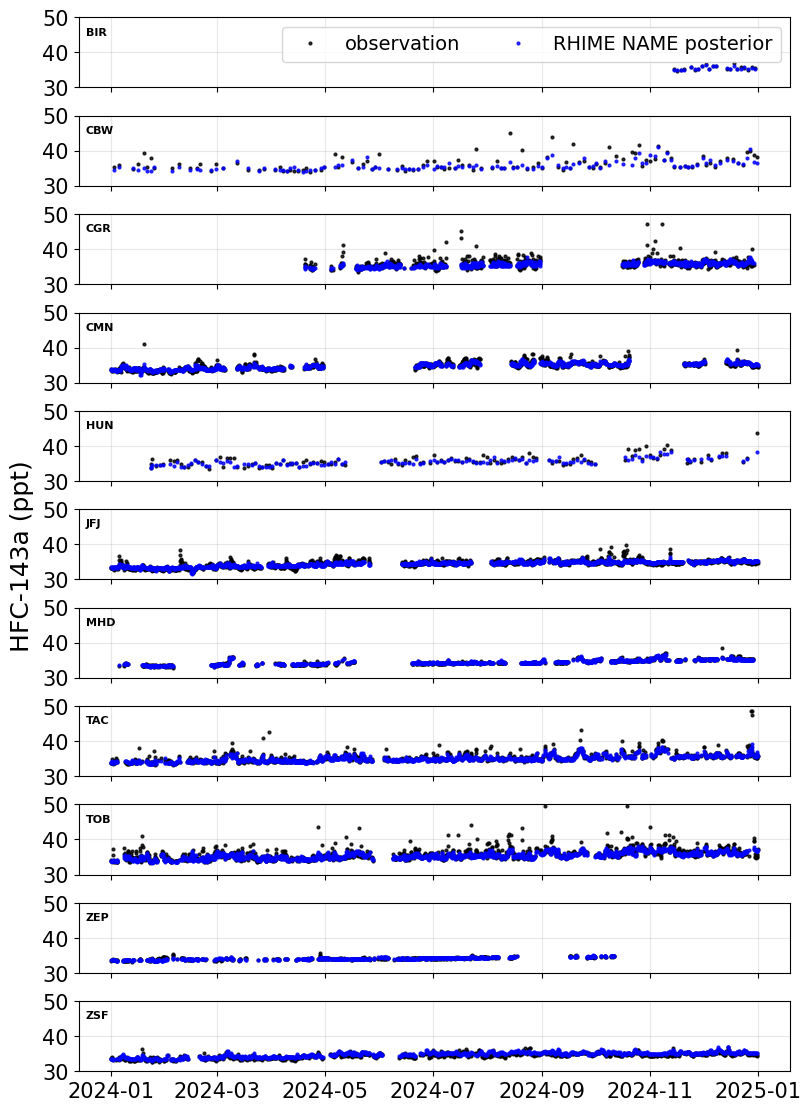

In [27]:
# site_list = ['MHD', 'CMN', 'JFJ', 'ZEP', 'TAC', 'TOB']
# site_list = ['CGR', 'BIR', 'CBW', 'ZSF', 'HUN']
site_list = None  # all sites
y_lim = [30, 50]  # e.g. [250, 350] or None for automatic limits
fig = plot_multiple_sites_mf_timeseries(ds_all_allsites, 
                                        include=include,
                                        species=species,
                                        model_colors=model_colors,
                                        model_labels=model_labels,
                                        config_data=config_data,
                                        site_list=site_list,
                                        y_lim=y_lim,
                                        time_freq_min=None,
                                        aggreg_month=False,
                                        )

In [ ]:
figname = f'{species}_mf_RHIME_NAME_2024'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Calculate and plot stats for the fit to obs:

Instructions to reproduce figures from the paper
- Fig. S2--S12 
- set `presentation_mode = False` for MF Figures

In [ ]:
from fluxy.operators.select import slice_mf
from fluxy.operators.mf import stats_mf
from fluxy.plots.mf_stats import plot_stats_mf


###################################
### edit variables in this block
stats_to_plot = ['pearson', 'bias', 'crmse']
what_to_compare = 'posterior_above_BC'
stats_ylim = {"pearson": [0,1]} #, "bias": [-1.5,0.5], "crmse": [0,1.5] }    # or set it to None
get_labels_from_file = True # If False, uses default labels. If True, uses labels from config file.


### Implemented statistics (stats_to_plot)
# pearson - Pearson correlation coefficient
# bias    - Mean difference
# rmse    - RMSE
# nrmse   - Normalised RMSE (division by mean observation)
# crmse   - Centered (bias-corrected) RMSE
# std_obs  - Standard deviation of observations 
# std_sim  - Standard deviation of simulation 
# std_res  - Standard deviation of residuals
# nn      - Number of observation-simulation pairs 
###################################

ds_all_allsites = slice_mf(ds_all_mf.copy(), 
                        start_date,
                        end_date,site=None,
                        baseline_site=baseline_site,
                        baseline_filename=baseline_filename,
                        data_dir=data_dir,
                        mf_units_print=mf_units_print)

model_labels = set_model_labels(models,config_data,get_labels_from_file)

for what_to_compare in ['posterior_above_BC', 'prior_above_BC']: #['posterior', 'prior']

    stats = stats_mf(ds_all_allsites, stats_type=what_to_compare)

    fig = plot_stats_mf(stats=stats, 
                        stats_to_plot=stats_to_plot, 
                        species=species,
                        model_colors=model_colors, 
                        model_labels=model_labels, 
                        config_data=config_data, 
                        mf_units_print=mf_units_print,
                        stats_type=what_to_compare,
                        stats_ylim=stats_ylim,
                        start_date=start_date, 
                        end_date=end_date)

    figname = f'{species}_mf_stats_{what_to_compare}'
    output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
    fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

In [ ]:
figname = f'{species}_mf_stats_{what_to_compare}'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Spatial maps of country/region fluxes

Instructions to reproduce figures from the paper
- Fig. 7--8 ==> run plot_flux_map_period_comparison with 'nid2026_name' and start_date = '2015-01-01', end_date = '2025-01-01'
- Fig. 10 ==> run plot_flux_map_combined_models_comparison with 'network_effect_name' and start_date = '2024-01-01', end_date = '2025-01-01'
- Fig. B1--B2 ==> run plot_flux_map_combined_models_comparison with 'nid2026' and start_date = '2022-01-01', end_date = '2025-01-01'
- Fig. B3 ==> run plot_flux_map_combined_models_comparison with 'network_effect_flexpart' and start_date = '2024-01-01', end_date = '2025-01-01'

with ylim for Fig. 7--8 and Fig. B1--B2
- [0,30] for HFC-134a
- [0,5] for HFC-143a
- [0,10] for HFC-125
- [0,5] for HFC-32

==> region = [-11, 20, 36, 60]

and with ylim for Fig. 10 and Fig. B3
- [0,20] for HFC-134a
- [0,2.5] for HFC-143a

==> region = [5, 25, 36, 51]

In [34]:
from fluxy.io import read_model_output
from fluxy.operators.select import slice_flux
from fluxy.config import set_model_labels
from fluxy.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'hfc134a'
start_date = '2024-01-01' 
end_date = '2025-01-01'
models = experiments['network_effect_name'] #'nid2026_name'
period = 'yearly' # inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']
flux_units_print = 'kg km-2 yr-1'
get_labels_from_file = False # If False, uses default labels. If True, uses labels from config file.
add_sites_to_flux = True # If true, add sites variable to flux dataset.
read_standard_run = True
###################################

ds_all_flux = read_model_output(data_dir, "flux", species, models, config_data, period=period, add_sites_to_flux=add_sites_to_flux, read_standard_run=read_standard_run)

ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,flux_units_print=flux_units_print)

model_labels = set_model_labels(models, config_data, get_labels_from_file)

/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/user/work/qq24644/miniconda3/envs/parisenv/lib/python3.13/site-packages/xarray/namedarray/core.py:264: UserWarning: Duplicate dimension names present: dimensions {'country'} appear more than once in dims=('time', 'country', 'country'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename 

#### Flux comparison between two periods

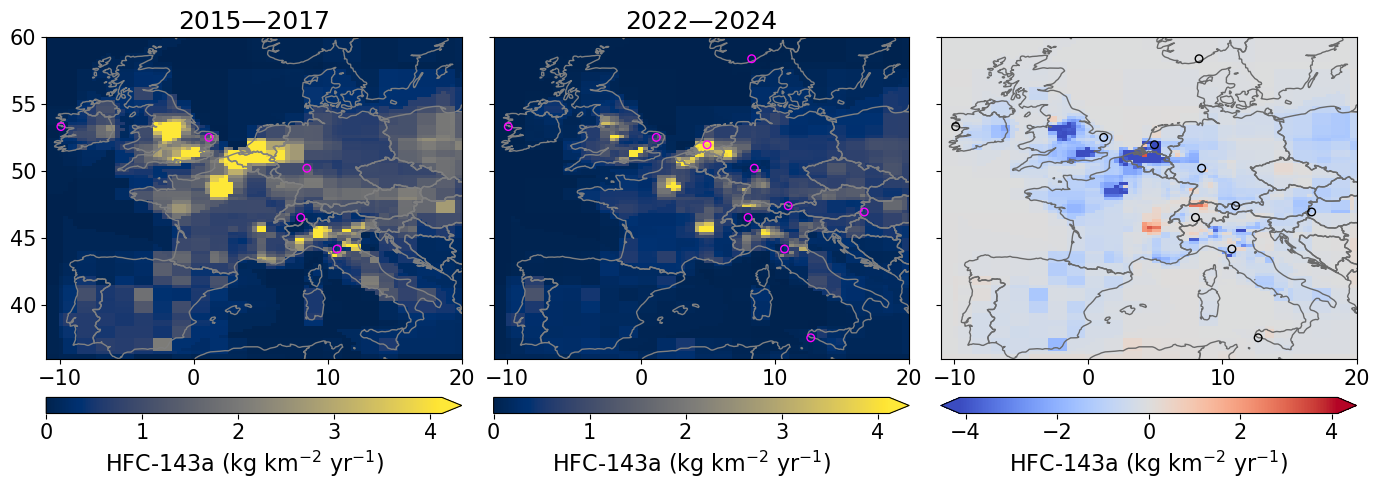

In [12]:
from fluxy.plots.flux_map import plot_flux_map_period_comparison

# Fig. 7--8
region = [-11, 20, 36, 60] #'NW_EU2'
start_dates = ['2015-01-01', '2022-01-01']
end_dates = ['2018-01-01', '2025-01-01']
plot_combined = True
add_sites = True    
add_markers = None
set_fluxlim = [0,30] # Set flux colorbar limits: e.g.[0,10]|'auto' ('auto' = 99th percentile of flux_posterior)
set_fluxlim_percentile = 0.99
var = 'flux_total_posterior_inversion_grid'  # Variable to be plotted. Extra options for 'posterior_prior_diff', 'posterior_mean_diff', 'posterior_prior_diff_inversion_grid', 'posterior_mean_diff_inversion_grid'.
###################################

fig = plot_flux_map_period_comparison(
                                ds_all_flux_scaled, 
                                var, 
                                species,
                                start_dates,
                                end_dates,
                                region,
                                config_data, 
                                model_labels, 
                                plot_combined=plot_combined, 
                                add_sites=add_sites, 
                                add_markers=add_markers, 
                                set_fluxlim = set_fluxlim, 
                                set_fluxlim_percentile=set_fluxlim_percentile, 
                                cmap='cividis', 
                                c_border='gray')

Save plot:

In [ ]:
figname = f'{species}_flux_map_name'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Flux comparison between two groups of models

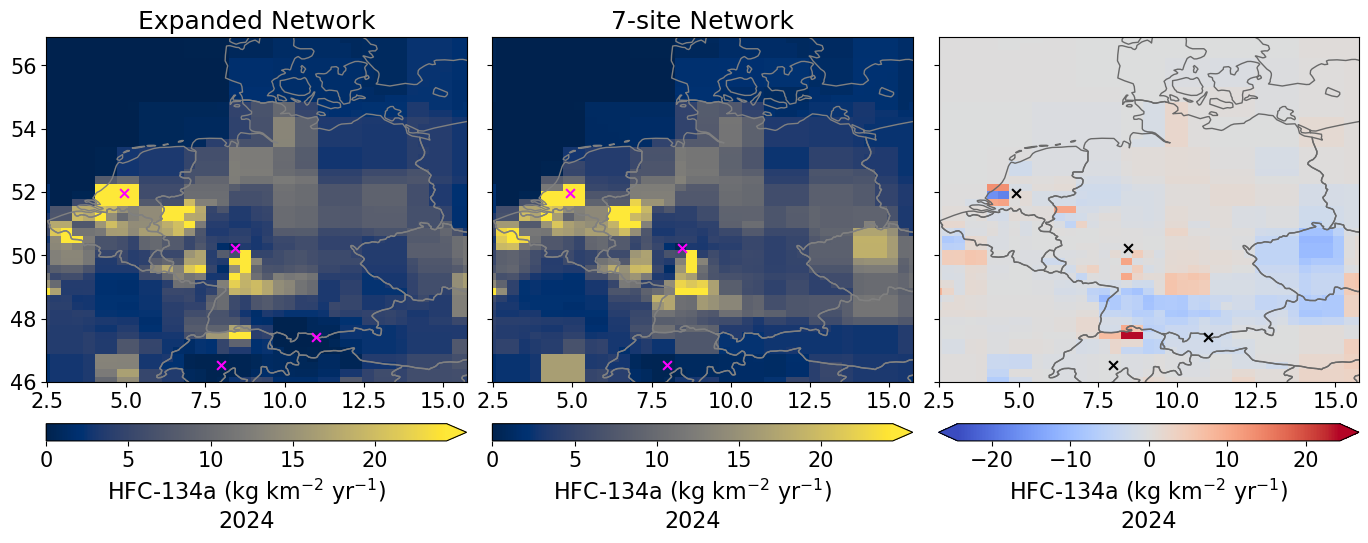

In [35]:
from fluxy.plots.flux_map import plot_flux_map_combined_models_comparison

###################################
### edit variables in this block
# Fig. 10
group_a = ['InTEM_NAME', 'ELRIS_NAME', 'RHIME_NAME'] # List of model names to be combined for the first group.
group_b = ['InTEM_NAME_7sites', 'ELRIS_NAME_7sites', 'RHIME_NAME_7sites'] # List of model names to be combined for the second group.
group_a_label = "Expanded Network" # Label for the first group of combined models.
group_b_label = "7-site Network" # Label for the second group of combined models.

# Fig. B1--B2
# group_a = ['InTEM_FLEXPART', 'ELRIS_FLEXPART', 'RHIME_FLEXPART'] # List of model names to be combined for the first group.
# group_b = ['InTEM_NAME', 'ELRIS_NAME', 'RHIME_NAME'] # List of model names to be combined for the second group.
# group_a_label = "FLEXPART-based mean" # Label for the first group of combined models.
# group_b_label = "NAME-based mean" # Label for the second group of combined models.

# Fig. B3
# group_a = ['InTEM_FLEXPART', 'ELRIS_FLEXPART', 'RHIME_FLEXPART'] # List of model names to be combined for the first group.
# group_b = ['InTEM_FLEXPART_7sites', 'ELRIS_FLEXPART_7sites', 'RHIME_FLEXPART_7sites'] # List of model names to be combined for the second group.
# group_a_label = "Expanded Network" # Label for the first group of combined models.
# group_b_label = "7-site Network" # Label for the second group of combined models.

var = "flux_total_posterior_inversion_grid"
region = [5, 25, 36, 51] # [-11, 20, 36, 60]
set_fluxlim = [0, 2.5]
add_sites = True
add_markers = ['naples', 'port_of_ravenna', 'vienna']
season = None
###################################

fig = plot_flux_map_combined_models_comparison(
    ds_all=ds_all_flux_scaled,
    var=var,
    group_a_models=group_a,
    group_b_models=group_b,
    species=species,
    region=region,
    config_data=config_data,
    group_a_label=group_a_label,
    group_b_label=group_b_label,
    add_sites=add_sites,
    add_markers=add_markers,
    season=season,
    set_fluxlim=set_fluxlim,
    cmap='cividis', c_border='gray'
)

Save plot:

In [33]:
figname = f'{species}_network_effect_name'
# figname = f'{species}_network_effect_flexpart'
# figname = f'{species}_flux_map_flexpartVSname'
output_path = f'/user/home/qq24644/my_paris/HFC_paper/figures/{figname}.png'
fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)